# Visualize two or more numerical variables
## Scatter plots
### Basic scatter plots

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

covid_totals = pd.read_csv("../05-data_cleaning/data/covidtotals.csv")


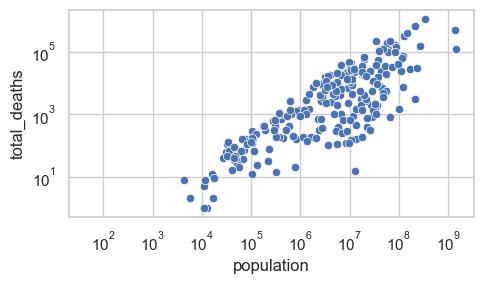

In [20]:
# let's inspect the relationship between population and total_deaths using a scatter plot


fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(5,3), tight_layout=True)
sns.set_theme(style="whitegrid")

sns.scatterplot(x=covid_totals['population'],
                y=covid_totals['total_deaths'],
                ax=ax)

plt.xscale('log')
plt.yscale('log')


### grouped scatter plot

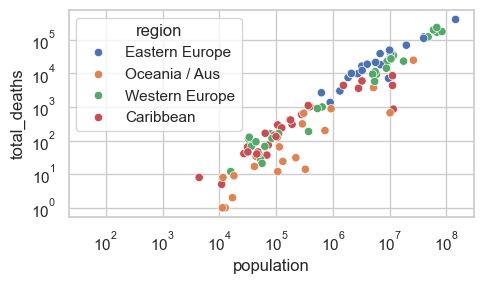

In [21]:
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(5,3), tight_layout=True)
sns.set_theme(style="whitegrid")

sns.scatterplot(data=covid_totals[covid_totals['region'].isin(['Western Europe', 'Caribbean', 'Oceania / Aus', 'Eastern Europe'])],
                x='population',
                y='total_deaths',
                hue='region',
                ax=ax)

plt.xscale('log')
plt.yscale('log')

### Regression plot
Usually we use sns.regplot

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

covid_totals = pd.read_csv("../05-data_cleaning/data/covidtotals.csv")
covid_totals['population_log'] = np.log1p(covid_totals['population']).fillna(0)
covid_totals['total_cases_log'] = np.log1p(covid_totals['total_cases']).fillna(0)

Text(0, 0.5, 'Total COVID Cases (log)')

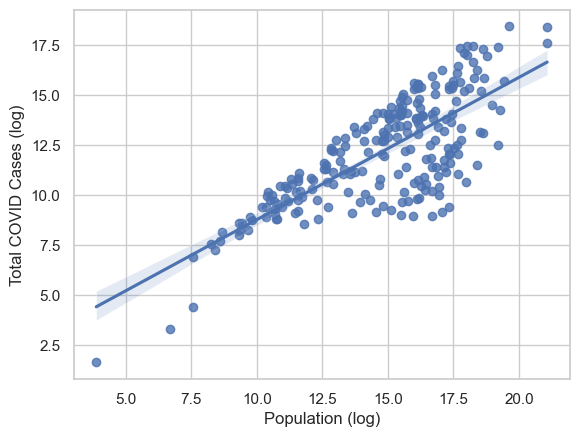

In [26]:
# Plot a simple regression plot

sns.regplot(data=covid_totals, x='population_log', y='total_cases_log')
sns.set_theme(style="whitegrid")

plt.xlabel("Population (log)")
plt.ylabel("Total COVID Cases (log)")


Text(60.33078906250002, 0.5, 'Total COVID cases (log)')

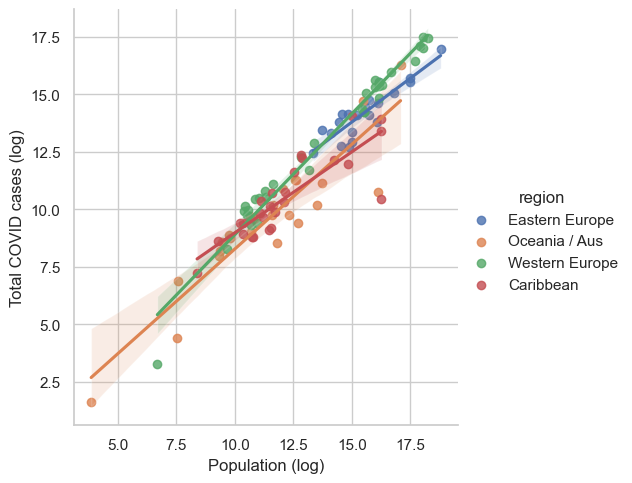

In [27]:
# Plot a grouped regression plot
sns.set_theme(style="whitegrid")
sns.lmplot(data=covid_totals[covid_totals['region'].isin(['Western Europe', 'Caribbean', 'Oceania / Aus', 'Eastern Europe'])], x='population_log', y='total_cases_log', hue='region')

plt.xlabel("Population (log)")
plt.ylabel("Total COVID cases (log)")

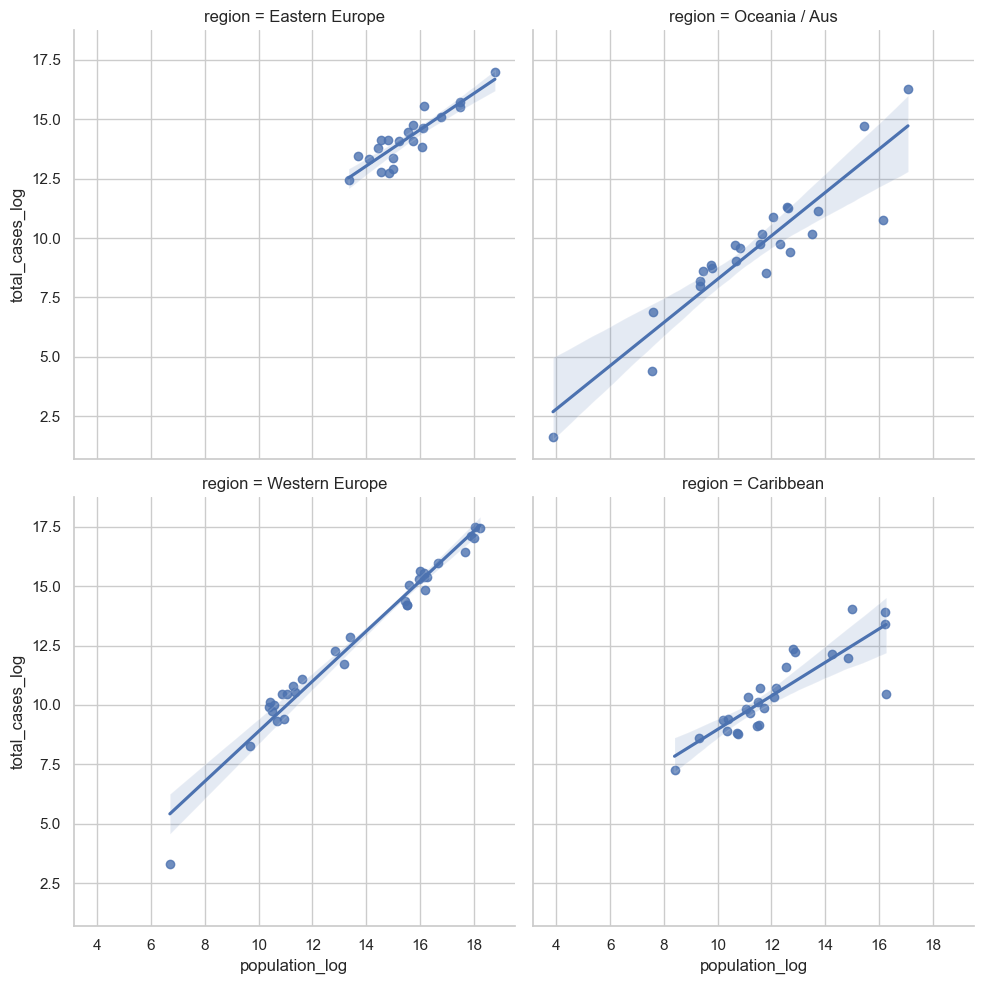

In [28]:
# or multiple panels


g=sns.lmplot(data=covid_totals[covid_totals['region'].isin(['Western Europe', 'Caribbean', 'Oceania / Aus', 'Eastern Europe'])], x='population_log', y='total_cases_log', col='region', col_wrap=2)


### Scatterplot with KDE

Example from seaborn official [website](https://seaborn.pydata.org/examples/layered_bivariate_plot.html)


<Axes: >

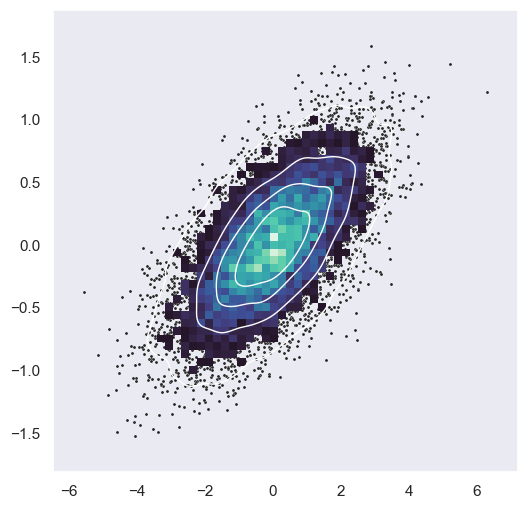

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

# Simulate data from a bivariate Gaussian
n = 10000
mean = [0, 0]
cov = [(2, .4), (.4, .2)]
rng = np.random.RandomState(0)
x, y = rng.multivariate_normal(mean, cov, n).T

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=50, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)

## Bubble chart